<a href="https://colab.research.google.com/github/AleximperV/ThucHanhDeepLearning/blob/main/Tuan_2/Bai1VaLyThuyet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

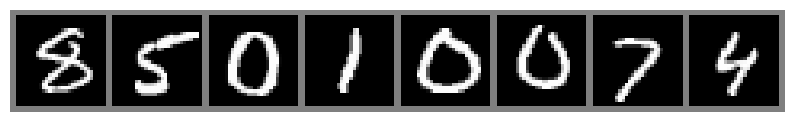

Nhãn tương ứng: 8 5 0 1 0 0 7 4


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. TIỀN XỬ LÝ VÀ TẢI DỮ LIỆU (DATALOADER)
# ==========================================
# Chuyển đổi ma trận pixel thành Tensor và chuẩn hóa giá trị về khoảng [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Tải tập Train và Test trực tiếp từ torchvision
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# ==========================================
# 2. XÂY DỰNG KIẾN TRÚC MẠNG CNN
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Khối trích xuất đặc trưng (Feature Extraction)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Khối phân loại (Classification)
        # Kích thước tensor sau 2 lần MaxPool: 28x28 -> 14x14 -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 đầu ra tương ứng 10 chữ số

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # Ép phẳng tensor để đưa vào lớp Linear
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()

# ==========================================
# 3. TRỰC QUAN HÓA DỮ LIỆU ĐẦU VÀO
# ==========================================
def imshow(img):
    img = img / 2 + 0.5  # Un-normalize để đưa về khoảng [0, 1]
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    # Sử dụng tông màu sáng, viền biểu đồ tối giản với màu Navy (#1B3A68)
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.gca().spines['top'].set_color('#1B3A68')
    plt.gca().spines['bottom'].set_color('#1B3A68')
    plt.gca().spines['left'].set_color('#1B3A68')
    plt.gca().spines['right'].set_color('#1B3A68')
    plt.axis('off')
    plt.show()

# Lấy thử một batch dữ liệu và hiển thị
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Hiển thị 8 ảnh đầu tiên trong batch
imshow(torchvision.utils.make_grid(images[:8]))
print('Nhãn tương ứng:', ' '.join(f'{labels[j].item()}' for j in range(8)))

Kích thước dữ liệu gốc: (60000, 784) (60000,) (10000, 784) (10000,)

Cấu trúc mô hình ban đầu:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9164 - loss: 0.3042 - val_accuracy: 0.9753 - val_loss: 0.0832
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9763 - loss: 0.0785 - val_accuracy: 0.9830 - val_loss: 0.0622
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9823 - loss: 0.0595 - val_accuracy: 0.9850 - val_loss: 0.0567
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0485 - val_accuracy: 0.9865 - val_loss: 0.0488
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9873 - loss: 0.0421 - val_accuracy: 0.9878 - val_loss: 0.0485
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0369 - val_accuracy: 0.9868 - val_loss: 0.0450
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9895 - loss: 0.0331 - val_accuracy: 0.9883 - val_loss: 0.0391
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9914 - loss: 0

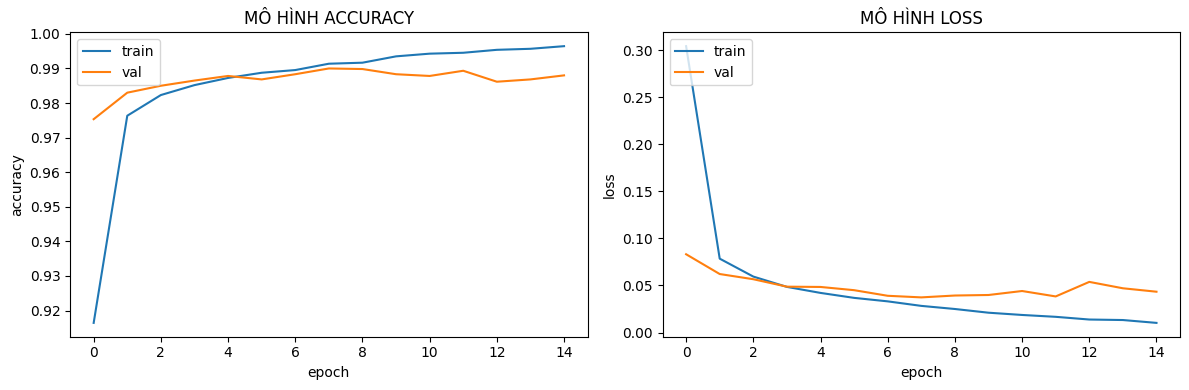


Đánh giá trên tập test...
313/313 - 1s - 4ms/step - accuracy: 0.9900 - loss: 0.0357

--- KẾT QUẢ TRÊN TẬP TEST ---
Test loss: 0.035703450441360474
Test accuracy: 0.9900000095367432

Tiến hành dự báo thử nghiệm trên ảnh đầu tiên của tập test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Xác suất dự báo cho từng lớp:
 [[1.6831659e-13 4.2536669e-13 2.2111227e-08 2.0462156e-07 1.4943043e-15
  2.2703906e-11 2.6358655e-22 9.9999976e-01 9.2752498e-12 1.7416539e-09]]
Nhãn dự báo: 7 | Nhãn thực tế: 7


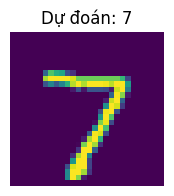


Đang lưu tham số mô hình vào file 'cnn.weights.h5'...

--- TIẾN HÀNH KHỞI TẠO LẠI MÔ HÌNH MỚI TINH ĐỂ THỬ TÍNH NĂNG NẠP ---
Đang nạp lại bộ trọng số (weights) từ 'cnn.weights.h5' vào mô hình mới...
Thử nghiệm dự báo ảnh thứ 2 (chỉ số index 1) bằng mô hình vừa nạp lại...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Nhãn dự báo từ mô hình vừa phục hồi: 2 | Nhãn thực tế: 2


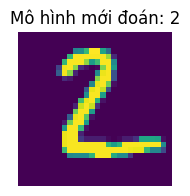

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# --- BƯỚC 1: ĐỌC DỮ LIỆU ---
mnist_train = '/content/drive/MyDrive/mnist_train.csv'
mnist_test = '/content/drive/MyDrive/mnist_test.csv'

# Đoạn code dự phòng nếu bạn chưa mount Drive hoặc sai đường dẫn
import os
if not os.path.exists(mnist_train):
    print("Không tìm thấy file trong Drive, chuyển sang dùng sample_data mặc định...")
    mnist_train = '/content/sample_data/mnist_train_small.csv'
    mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

# Tách features (X) và nhãn (y)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print("Kích thước dữ liệu gốc:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# --- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa giá trị pixel
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Reshape dữ liệu về dạng ảnh 2D
X_train = X_train.to_numpy().reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.to_numpy().reshape(X_test.shape[0], 28, 28, 1)

# Chuyển nhãn sang one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# --- BƯỚC 3: XÂY DỰNG MÔ HÌNH CNN ---
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

print("\nCấu trúc mô hình ban đầu:")
model.summary()

# --- BƯỚC 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VAL ---
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nBắt đầu huấn luyện...")
model_fit = model.fit(X_train, y_train_cat, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

# --- BƯỚC 5: VẼ ĐỒ THỊ ĐÁNH GIÁ (LOSS & ACCURACY) ---
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('MÔ HÌNH ACCURACY')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('MÔ HÌNH LOSS')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# --- BƯỚC 6: ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\nĐánh giá trên tập test...")
score = model.evaluate(X_test, y_test_cat, verbose=2)
print('\n--- KẾT QUẢ TRÊN TẬP TEST ---')
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# --- BƯỚC 7: DỰ BÁO NHÃN CHO 1 ẢNH BẤT KỲ ---
print("\nTiến hành dự báo thử nghiệm trên ảnh đầu tiên của tập test...")
predict_0 = model.predict(X_test[:1])
predicted_label = np.argmax(predict_0)
actual_label = int(y_test.iloc[0])

print(f"Xác suất dự báo cho từng lớp:\n {predict_0}")
print(f"Nhãn dự báo: {predicted_label} | Nhãn thực tế: {actual_label}")

# Trực quan hóa ảnh được dự báo
plt.figure(figsize=(2,2))
plt.imshow(X_test[0].reshape(28, 28))
plt.title(f"Dự đoán: {predicted_label}")
plt.axis('off')
plt.show()

# --- BƯỚC 8: LƯU THAM SỐ MÔ HÌNH (Đã sửa đuôi file cho Keras 3) ---
print("\nĐang lưu tham số mô hình vào file 'cnn.weights.h5'...")
model.save_weights('cnn.weights.h5')

# --- BƯỚC 9: KHỞI TẠO LẠI VÀ NẠP LẠI THAM SỐ ---
print("\n--- TIẾN HÀNH KHỞI TẠO LẠI MÔ HÌNH MỚI TINH ĐỂ THỬ TÍNH NĂNG NẠP ---")
new_model = Sequential()
new_model.add(Input(shape=input_shape))
new_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Flatten())
new_model.add(Dense(units=10, activation='softmax'))

# Nạp lại tham số đã lưu trước đó (Đã sửa đuôi file cho Keras 3)
print("Đang nạp lại bộ trọng số (weights) từ 'cnn.weights.h5' vào mô hình mới...")
new_model.load_weights('cnn.weights.h5')

# Dự báo thử nghiệm bằng mô hình mới nạp để chứng minh nó hoạt động
print("Thử nghiệm dự báo ảnh thứ 2 (chỉ số index 1) bằng mô hình vừa nạp lại...")
predict_1 = new_model.predict(X_test[1:2])
predicted_label_new = np.argmax(predict_1)
actual_label_new = int(y_test.iloc[1])

print(f"Nhãn dự báo từ mô hình vừa phục hồi: {predicted_label_new} | Nhãn thực tế: {actual_label_new}")

# Trực quan hóa ảnh thứ 2
plt.figure(figsize=(2,2))
plt.imshow(X_test[1].reshape(28, 28))
plt.title(f"Mô hình mới đoán: {predicted_label_new}")
plt.axis('off')
plt.show()

Đang tải bộ dữ liệu CIFAR-10...
Kích thước dữ liệu gốc:
X_train: (50000, 32, 32, 3)  | y_train: (50000, 1)
X_test: (10000, 32, 32, 3)   | y_test: (10000, 1)

Cấu trúc mô hình CNN cho CIFAR-10:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4651 - loss: 1.4753 - val_accuracy: 0.5544 - val_loss: 1.2510
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6300 - loss: 1.0521 - val_accuracy: 0.6410 - val_loss: 1.0130
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6945 - loss: 0.8759 - val_accuracy: 0.6970 - val_loss: 0.8896
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7368 - loss: 0.7569 - val_accuracy: 0.7062 - val_loss: 0.8611
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7692 - loss: 0.6642 - val_accuracy: 0.7242 - val_loss: 0.8180
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7952 - loss: 0.5873 - val_accuracy: 0.7358 - val_loss: 0.7918
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8171 - loss: 0.5213 - val_accuracy: 0.7362 - val_loss: 0.7917
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.843

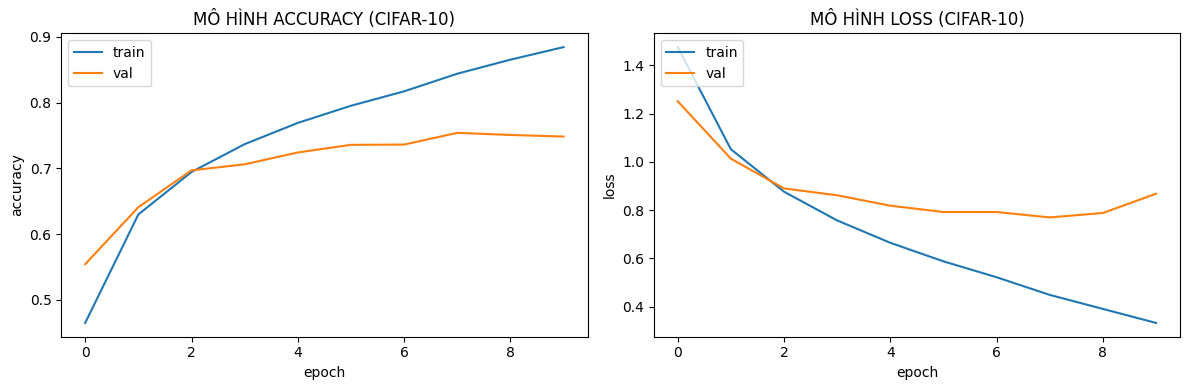


Đánh giá mô hình trên tập kiểm thử (Test set)...
313/313 - 1s - 5ms/step - accuracy: 0.7283 - loss: 0.9323

--- KẾT QUẢ TRÊN TẬP TEST ---
Test loss: 0.9323326349258423
Test accuracy: 0.7282999753952026

Tiến hành dự báo thử nghiệm ảnh đầu tiên của tập test...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
Nhãn dự báo: cat | Nhãn thực tế: cat


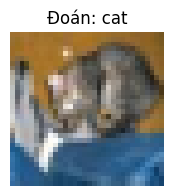


Đang lưu trọng số vào file 'cifar10_cnn.weights.h5'...

--- KIỂM TRA TÍNH NĂNG NẠP LẠI TRÊN MÔ HÌNH MỚI TINH ---
Thử nghiệm dự báo ảnh thứ 2 bằng mô hình vừa nạp lại...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
Mô hình nạp lại đoán: ship | Thực tế: ship


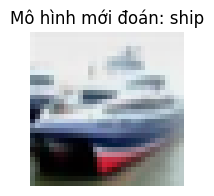

In [6]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# --- BƯỚC 1: NẠP DỮ LIỆU CIFAR-10 TÍCH HỢP SẴN ---
print("Đang tải bộ dữ liệu CIFAR-10...")
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Kích thước dữ liệu gốc:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_test:", X_test.shape, "  | y_test:", y_test.shape)

# Danh sách tên các nhãn theo thứ tự từ 0 đến 9
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# --- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---
num_classes = 10
input_shape = (32, 32, 3)

# Chuẩn hóa giá trị pixel về khoảng [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Chuyển nhãn sang định dạng one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# --- BƯỚC 3: XÂY DỰNG MÔ HÌNH CNN CHO ẢNH MÀU ---
model = Sequential()
model.add(Input(shape=input_shape))

# Tầng Convolutional 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Tầng Convolutional 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Tầng Convolutional 3
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Phẳng hóa và Tầng phân loại
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

print("\nCấu trúc mô hình CNN cho CIFAR-10:")
model.summary()

# --- BƯỚC 4: HUẤN LUYỆN MÔ HÌNH ---
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nBắt đầu huấn luyện (10 epochs)...")
model_fit = model.fit(X_train, y_train_cat, batch_size=64, epochs=10, validation_split=0.1, verbose=1)

# --- BƯỚC 5: VẼ ĐỒ THỊ ĐÁNH GIÁ TRỰC QUAN ---
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('MÔ HÌNH ACCURACY (CIFAR-10)')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('MÔ HÌNH LOSS (CIFAR-10)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# --- BƯỚC 6: ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\nĐánh giá mô hình trên tập kiểm thử (Test set)...")
score = model.evaluate(X_test, y_test_cat, verbose=2)
print('\n--- KẾT QUẢ TRÊN TẬP TEST ---')
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# --- BƯỚC 7: DỰ BÁO THỬ NGHIỆM TRÊN 1 ẢNH CỤ THỂ ---
print("\nTiến hành dự báo thử nghiệm ảnh đầu tiên của tập test...")
predict_0 = model.predict(X_test[:1])
predicted_idx = np.argmax(predict_0)
actual_idx = int(y_test[0][0])

print(f"Nhãn dự báo: {class_names[predicted_idx]} | Nhãn thực tế: {class_names[actual_idx]}")

# Hiển thị ảnh màu thực tế
plt.figure(figsize=(2,2))
plt.imshow(X_test[0])
plt.title(f"Đoán: {class_names[predicted_idx]}")
plt.axis('off')
plt.show()

# --- BƯỚC 8: LƯU THAM SỐ MÔ HÌNH ---
print("\nĐang lưu trọng số vào file 'cifar10_cnn.weights.h5'...")
model.save_weights('cifar10_cnn.weights.h5')

# --- BƯỚC 9: TÁI KHỞI TẠO VÀ NẠP LẠI MÔ HÌNH ---
print("\n--- KIỂM TRA TÍNH NĂNG NẠP LẠI TRÊN MÔ HÌNH MỚI TINH ---")
new_model = Sequential()
new_model.add(Input(shape=input_shape))
new_model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Flatten())
new_model.add(Dense(128, activation='relu'))
new_model.add(Dense(units=10, activation='softmax'))

# Nạp bộ tham số đã lưu
new_model.load_weights('cifar10_cnn.weights.h5')

# Dự báo thử ảnh thứ 2 (chỉ số index 1) bằng mô hình mới phục hồi
print("Thử nghiệm dự báo ảnh thứ 2 bằng mô hình vừa nạp lại...")
predict_1 = new_model.predict(X_test[1:2])
predicted_idx_new = np.argmax(predict_1)
actual_idx_new = int(y_test[1][0])

print(f"Mô hình nạp lại đoán: {class_names[predicted_idx_new]} | Thực tế: {class_names[actual_idx_new]}")

# Hiển thị ảnh thứ 2
plt.figure(figsize=(2,2))
plt.imshow(X_test[1])
plt.title(f"Mô hình mới đoán: {class_names[predicted_idx_new]}")
plt.axis('off')
plt.show()